<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day11-rnns-lstm-gru-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 11 — RNNs, LSTM, BiLSTM, GRU in code {.unnumbered}

This notebook implements, from scratch and with real data, the ideas from the Day 11 page: why gradients vanish or explode through many recurrent steps, how LSTM's gates fix it, and how BiLSTM/GRU compare — ending with a real signal-peptide detection case study on live UniProt data, comparing a sliding-window baseline against SimpleRNN, LSTM, BiLSTM, and GRU taggers.

Adapted from this repo's own `notebooks/ch09.ipynb`, `notebooks/ch10.ipynb`, and `notebooks/ch10_signal_peptide_detection.ipynb` (the last one already builds the SignalP dataset fetch and the SlidingWindow/SimpleRNN/LSTM comparison; this notebook extends it with BiLSTM and GRU).

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1) Why gradients vanish or explode through many steps

Backpropagation through $k$ time steps multiplies by (roughly) the same recurrent weight $k$ times. If that factor's magnitude is below 1, the product shrinks toward zero (vanishing); if above 1, it blows up (exploding) — this is the same "eigenvalue of the recurrence" framing Ekman's Chapter 9 slides use.

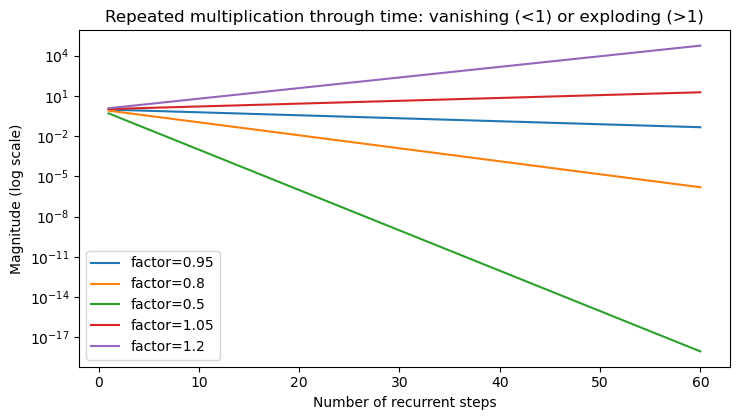

In [2]:
depth = np.arange(1, 61)
plt.figure(figsize=(7.5, 4.3))
for factor in [0.95, 0.8, 0.5, 1.05, 1.2]:
    plt.plot(depth, factor ** depth, label=f"factor={factor}")
plt.yscale("log")
plt.xlabel("Number of recurrent steps")
plt.ylabel("Magnitude (log scale)")
plt.title("Repeated multiplication through time: vanishing (<1) or exploding (>1)")
plt.legend()
plt.tight_layout()
plt.savefig("../figs/day11-vanishing-exploding.png", dpi=130)
plt.show()

Concretely: at factor 0.8, after 60 steps the signal is $0.8^{60} \approx$

In [3]:
print(f"{0.8**60:.2e}")
print(f"{1.2**60:.2e}")

1.53e-06
5.63e+04


## 2) LSTM: gates and the Constant Error Carousel

A plain RNN's hidden state is overwritten every step, which is exactly why the multiplicative decay above happens. An LSTM instead keeps a separate **cell state** $c_t$ that gates control additively: a **forget gate** $f_t$ decides how much of the old cell state to keep, an **input gate** $i_t$ decides how much of a new candidate value $\tilde c_t$ to add, and an **output gate** $o_t$ decides how much of the cell state to expose as the hidden state:

$$
f_t = \sigma(W_f[h_{t-1}, x_t]), \quad i_t = \sigma(W_i[h_{t-1}, x_t]), \quad \tilde c_t = \tanh(W_c[h_{t-1}, x_t])
$$
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t, \qquad o_t = \sigma(W_o[h_{t-1}, x_t]), \qquad h_t = o_t \odot \tanh(c_t)
$$

When $f_t \approx 1$ and $i_t \approx 0$, $c_t \approx c_{t-1}$ — the cell state is carried forward almost unchanged, sidestepping the repeated-multiplication decay above. This is why LSTM's forget-gate bias is conventionally initialized to $+1$ (favoring "remember" at the start of training, adapted from `ch10.ipynb`'s `ExplicitLSTMCell`).

In [4]:
class ExplicitLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        in_dim = input_size + hidden_size
        self.Wf = nn.Linear(in_dim, hidden_size)
        self.Wi = nn.Linear(in_dim, hidden_size)
        self.Wc = nn.Linear(in_dim, hidden_size)
        self.Wo = nn.Linear(in_dim, hidden_size)
        with torch.no_grad():
            self.Wf.bias.fill_(1.0)  # forget-gate bias init to 1

    def forward(self, x_t, h_prev, c_prev):
        z = torch.cat([h_prev, x_t], dim=1)
        f_t = torch.sigmoid(self.Wf(z))
        i_t = torch.sigmoid(self.Wi(z))
        c_tilde = torch.tanh(self.Wc(z))
        c_t = f_t * c_prev + i_t * c_tilde
        o_t = torch.sigmoid(self.Wo(z))
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t

torch.manual_seed(0)
cell = ExplicitLSTMCell(input_size=4, hidden_size=3)
x_t = torch.randn(1, 4)
h0 = torch.zeros(1, 3)
c0 = torch.zeros(1, 3)
h1, c1 = cell(x_t, h0, c0)
print("h1:", h1.detach().numpy().round(4))
print("c1:", c1.detach().numpy().round(4))

# cross-check against PyTorch's own nn.LSTMCell with the same weights.
# ExplicitLSTMCell concatenates z = [h_prev, x_t] before each Linear, so a
# gate's weight columns [0:hidden_size] act on h_prev and [hidden_size:] act
# on x_t -- the opposite split/order from nn.LSTMCell's separate weight_ih
# (acts on x_t) / weight_hh (acts on h_prev). nn.LSTMCell packs gates in
# order i, f, g, o.
hidden_size = 3
ref = nn.LSTMCell(4, hidden_size)
with torch.no_grad():
    W_ih = torch.cat([cell.Wi.weight[:, hidden_size:], cell.Wf.weight[:, hidden_size:], cell.Wc.weight[:, hidden_size:], cell.Wo.weight[:, hidden_size:]], dim=0)
    W_hh = torch.cat([cell.Wi.weight[:, :hidden_size], cell.Wf.weight[:, :hidden_size], cell.Wc.weight[:, :hidden_size], cell.Wo.weight[:, :hidden_size]], dim=0)
    b_ih = torch.cat([cell.Wi.bias, cell.Wf.bias, cell.Wc.bias, cell.Wo.bias])
    ref.weight_ih.copy_(W_ih)
    ref.weight_hh.copy_(W_hh)
    ref.bias_ih.copy_(b_ih)
    ref.bias_hh.zero_()
h1_ref, c1_ref = ref(x_t, (h0, c0))
print("max abs diff h:", (h1 - h1_ref).abs().max().item())
print("max abs diff c:", (c1 - c1_ref).abs().max().item())

h1: [[ 0.1534 -0.1484 -0.0556]]
c1: [[ 0.2277 -0.2663 -0.1956]]
max abs diff h: 0.0
max abs diff c: 0.0


## 3) Bidirectional LSTM and GRU

Two real refinements on top of plain LSTM, both used below on the real SignalP case study:

- **Bidirectional (BiLSTM)**: runs one LSTM left-to-right and a second right-to-left over the same sequence, concatenating their hidden states at each position. Whether a residue is part of a signal peptide depends on context from *both* directions (e.g. the h-region's hydrophobic stretch is defined relative to residues on both sides) — a plain, forward-only LSTM can only see what came before.
- **GRU (Gated Recurrent Unit)**: merges LSTM's three gates into two (a reset gate and an update gate) and drops the separate cell state, folding everything into a single hidden state. Fewer parameters, often comparably good in practice — this is a real empirical question the case study below answers on real data rather than asserting one architecture is "better."

## 4) Case study: SignalP — signal-peptide detection

Fetch a real, live signal-peptide dataset from UniProtKB (reviewed Swiss-Prot entries with a `ft_signal` annotation), following `notebooks/ch10_signal_peptide_detection.ipynb`.

In [5]:
from pathlib import Path
import re
import urllib.parse
import urllib.request

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, precision_recall_curve
)
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR = Path("data/signal_peptides")
DATA_DIR.mkdir(parents=True, exist_ok=True)

UNIPROT_QUERY = "reviewed:true AND length:[40 TO 800]"
FIELDS = "accession,sequence,ft_signal"
MAX_RECORDS = 3000

def fetch_uniprot_tsv(query, fields, max_records=3000):
    base = "https://rest.uniprot.org/uniprotkb/search"
    params = {"query": query, "fields": fields, "format": "tsv", "size": 500}
    next_url = base + "?" + urllib.parse.urlencode(params)
    chunks, n_rows = [], 0
    while next_url and n_rows < max_records:
        req = urllib.request.Request(next_url, headers={"User-Agent": "EkmanTeaching/1.0"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            text = resp.read().decode("utf-8", errors="ignore")
            lines = text.strip().splitlines()
            if not lines:
                break
            if not chunks:
                chunks.extend(lines)
                n_rows += max(0, len(lines) - 1)
            else:
                chunks.extend(lines[1:])
                n_rows += len(lines) - 1
            link = resp.headers.get("Link", "")
            m = re.search(r"<([^>]+)>;\s*rel=\"next\"", link)
            next_url = m.group(1) if m else None
    return "\n".join(chunks) + "\n"

def parse_signal_ranges(signal_field):
    if signal_field is None:
        return []
    txt = str(signal_field).strip()
    if txt == "" or txt.lower() == "nan":
        return []
    ranges = []
    for m in re.finditer(r"SIGNAL\s+(\d+)\.\.(\d+)", txt):
        ranges.append((int(m.group(1)), int(m.group(2))))
    return ranges

tsv_text = fetch_uniprot_tsv(UNIPROT_QUERY, FIELDS, MAX_RECORDS)
rows = [r.split("\t") for r in tsv_text.strip().splitlines()]
header, rows = rows[0], rows[1:]
print("Columns:", header)
print("Rows fetched:", len(rows))

acc_i, seq_i, sig_i = header.index("Entry"), header.index("Sequence"), header.index("Signal peptide")
sequences, labels = [], []
for r in rows:
    if len(r) <= max(acc_i, seq_i, sig_i):
        continue
    seq = r[seq_i]
    ranges = parse_signal_ranges(r[sig_i])
    y = np.zeros(len(seq), dtype=np.int64)
    for (s, e) in ranges:
        y[s - 1:e] = 1
    sequences.append(seq)
    labels.append(y)

n_with_sp = sum(1 for y in labels if y.sum() > 0)
print(f"Proteins: {len(sequences)}  |  with an annotated signal peptide: {n_with_sp} ({n_with_sp/len(sequences):.1%})")

Columns: ['Entry', 'Sequence', 'Signal peptide']
Rows fetched: 3000
Proteins: 2995  |  with an annotated signal peptide: 602 (20.1%)


### Train/test split and residue-window baseline

Train on the N-terminal 70 residues only (where signal peptides live), following the source notebook's setup exactly.

In [6]:
NTERM_LEN = 70
WINDOW = 15
TRAIN_FRAC = 0.8

idx = np.arange(len(sequences))
rng = np.random.default_rng(0)
rng.shuffle(idx)
split = int(TRAIN_FRAC * len(idx))
idx_train, idx_test = idx[:split], idx[split:]

seq_train = [sequences[i] for i in idx_train]
lab_train = [labels[i] for i in idx_train]
seq_test = [sequences[i] for i in idx_test]
lab_test = [labels[i] for i in idx_test]
print(f"Train proteins: {len(seq_train)} | Test proteins: {len(seq_test)}")

AA = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {a: i for i, a in enumerate(AA)}
UNK_IDX = len(AA)
VOCAB_SIZE = len(AA) + 1

def aa_index(ch):
    return aa_to_idx.get(ch, UNK_IDX)

def make_residue_examples(seq_list, lab_list, nterm_len=70, window=15):
    r = window // 2
    X_idx, y = [], []
    for seq, yseq in zip(seq_list, lab_list):
        L = min(len(seq), nterm_len)
        for pos in range(L):
            w = [aa_index(seq[j]) if 0 <= j < L else UNK_IDX for j in range(pos - r, pos + r + 1)]
            X_idx.append(w)
            y.append(int(yseq[pos]))
    return np.array(X_idx, dtype=np.int64), np.array(y, dtype=np.int64)

def one_hot_flat(X_idx, vocab_size):
    n, w = X_idx.shape
    out = np.zeros((n, w * vocab_size), dtype=np.float32)
    for i in range(n):
        for p in range(w):
            out[i, p * vocab_size + X_idx[i, p]] = 1.0
    return out

Xtr_idx, ytr = make_residue_examples(seq_train, lab_train, NTERM_LEN, WINDOW)
Xte_idx, yte = make_residue_examples(seq_test, lab_test, NTERM_LEN, WINDOW)
print("Sliding-window residue samples train/test:", Xtr_idx.shape, Xte_idx.shape)
print("Positive rate train/test:", ytr.mean().round(4), yte.mean().round(4))

Xtr = one_hot_flat(Xtr_idx, VOCAB_SIZE)
Xte = one_hot_flat(Xte_idx, VOCAB_SIZE)

clf = SGDClassifier(loss="log_loss", alpha=1e-4, class_weight="balanced", max_iter=50, random_state=0)
clf.fit(Xtr, ytr)
proba_sw = clf.predict_proba(Xte)[:, 1]
pred_sw = (proba_sw >= 0.5).astype(np.int64)
metrics_sw = {
    "precision": precision_score(yte, pred_sw, zero_division=0),
    "recall": recall_score(yte, pred_sw, zero_division=0),
    "f1": f1_score(yte, pred_sw, zero_division=0),
    "mcc": matthews_corrcoef(yte, pred_sw),
    "auroc": roc_auc_score(yte, proba_sw),
    "aupr": average_precision_score(yte, proba_sw),
}
print("Sliding-window baseline:", {k: round(v, 4) for k, v in metrics_sw.items()})

Train proteins: 2396 | Test proteins: 599


Sliding-window residue samples train/test: (167482, 15) (41871, 15)
Positive rate train/test: 0.069 0.067


Sliding-window baseline: {'precision': 0.296, 'recall': 0.8884, 'f1': 0.444, 'mcc': 0.4595, 'auroc': 0.9405, 'aupr': 0.5876}


### Recurrent taggers: SimpleRNN, LSTM, BiLSTM, GRU

One shared model class, switched by `kind` — this is the real comparison the page reports.

In [7]:
def encode_protein_batch(seq_list, lab_list, nterm_len=70):
    X = np.full((len(seq_list), nterm_len), UNK_IDX, dtype=np.int64)
    Y = np.zeros((len(seq_list), nterm_len), dtype=np.float32)
    M = np.zeros((len(seq_list), nterm_len), dtype=np.float32)
    for i, (seq, yseq) in enumerate(zip(seq_list, lab_list)):
        L = min(len(seq), nterm_len)
        for j in range(L):
            X[i, j] = aa_index(seq[j])
            Y[i, j] = float(yseq[j])
            M[i, j] = 1.0
    return X, Y, M

X_train_seq, y_train_seq, m_train_seq = encode_protein_batch(seq_train, lab_train, NTERM_LEN)
X_test_seq, y_test_seq, m_test_seq = encode_protein_batch(seq_test, lab_test, NTERM_LEN)

train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq), torch.from_numpy(m_train_seq))
test_ds = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(y_test_seq), torch.from_numpy(m_test_seq))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)


class SeqTagger(nn.Module):
    """kind in {"rnn", "lstm", "bilstm", "gru"}."""
    def __init__(self, vocab_size, emb_dim=24, hid_dim=48, kind="rnn"):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        bidirectional = (kind == "bilstm")
        if kind in ("lstm", "bilstm"):
            self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True, bidirectional=bidirectional)
        elif kind == "gru":
            self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True, nonlinearity="tanh")
        out_dim = hid_dim * (2 if bidirectional else 1)
        self.out = nn.Linear(out_dim, 1)

    def forward(self, x):
        z = self.emb(x)
        h, _ = self.rnn(z)
        return self.out(h).squeeze(-1)


def n_params(model):
    return sum(p.numel() for p in model.parameters())


def train_sequence_model(model, train_loader, test_loader, epochs=6, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    def run_eval(loader):
        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for xb, yb, mb in loader:
                xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
                probs = torch.sigmoid(model(xb))
                keep = mb > 0
                all_p.append(probs[keep].detach().cpu().numpy())
                all_y.append(yb[keep].detach().cpu().numpy())
        p = np.concatenate(all_p).astype(np.float32)
        y = np.concatenate(all_y).astype(np.int64)
        pred = (p >= 0.5).astype(np.int64)
        return {
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "mcc": matthews_corrcoef(y, pred),
            "auroc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            "aupr": average_precision_score(y, p),
            "y": y, "proba": p,
        }

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb, mb in train_loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss_all = nn.functional.binary_cross_entropy_with_logits(logits, yb, reduction="none")
            loss = (loss_all * mb).sum() / mb.sum().clamp_min(1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            losses.append(float(loss.item()))
        val = run_eval(test_loader)
        print(f"  epoch {ep:02d} | loss {np.mean(losses):.4f} | f1 {val['f1']:.4f} | aupr {val['aupr']:.4f}")
    return run_eval(test_loader)


results = {"SlidingWindow": {**metrics_sw, "y": yte, "proba": proba_sw}}
param_counts = {}
for kind, name in [("rnn", "SimpleRNN"), ("lstm", "LSTM"), ("bilstm", "BiLSTM"), ("gru", "GRU")]:
    print(f"Training {name}...")
    model = SeqTagger(VOCAB_SIZE, kind=kind)
    param_counts[name] = n_params(model)
    results[name] = train_sequence_model(model, train_loader, test_loader, epochs=6, lr=1e-3)

print()
print("Parameter counts:", param_counts)

Training SimpleRNN...


  epoch 01 | loss 0.3986 | f1 0.0000 | aupr 0.0962
  epoch 02 | loss 0.2482 | f1 0.0000 | aupr 0.1188


  epoch 03 | loss 0.2414 | f1 0.0000 | aupr 0.1627
  epoch 04 | loss 0.2303 | f1 0.0000 | aupr 0.2767


  epoch 05 | loss 0.1860 | f1 0.0395 | aupr 0.4276
  epoch 06 | loss 0.1675 | f1 0.4036 | aupr 0.5384
Training LSTM...


  epoch 01 | loss 0.4867 | f1 0.0000 | aupr 0.1858
  epoch 02 | loss 0.2336 | f1 0.0071 | aupr 0.2446


...

  epoch 03 | loss 0.1679 | f1 0.1625 | aupr 0.5272
  epoch 04 | loss 0.1409 | f1 0.4336 | aupr 0.5981


  epoch 05 | loss 0.1240 | f1 0.5007 | aupr 0.6790
  epoch 06 | loss 0.1108 | f1 0.5901 | aupr 0.7139
Training GRU...


  epoch 01 | loss 0.4338 | f1 0.0000 | aupr 0.1929
  epoch 02 | loss 0.2147 | f1 0.0554 | aupr 0.4352


  epoch 03 | loss 0.1663 | f1 0.4173 | aupr 0.5517
  epoch 04 | loss 0.1518 | f1 0.4544 | aupr 0.5814


  epoch 05 | loss 0.1436 | f1 0.4689 | aupr 0.5976
  epoch 06 | loss 0.1393 | f1 0.4741 | aupr 0.6110

Parameter counts: {'SimpleRNN': 4105, 'LSTM': 14761, 'BiLSTM': 29017, 'GRU': 11209}


### Comparing all five models

Final test metrics

[SlidingWindow]
  precision: 0.2960
     recall: 0.8884
         f1: 0.4440
        mcc: 0.4595
       aupr: 0.5876
      auroc: 0.9405

[SimpleRNN]  (4,105 params)
  precision: 0.6799
     recall: 0.2870
         f1: 0.4036
        mcc: 0.4182
       aupr: 0.5384
      auroc: 0.9350

[LSTM]  (14,761 params)
  precision: 0.7333
     recall: 0.2392
         f1: 0.3608
        mcc: 0.3984
       aupr: 0.5776
      auroc: 0.9474

[BiLSTM]  (29,017 params)
  precision: 0.7754
     recall: 0.4763
         f1: 0.5901
        mcc: 0.5870
       aupr: 0.7139
      auroc: 0.9721

[GRU]  (11,209 params)
  precision: 0.7325
     recall: 0.3504
         f1: 0.4741
        mcc: 0.4844
       aupr: 0.6110
      auroc: 0.9508


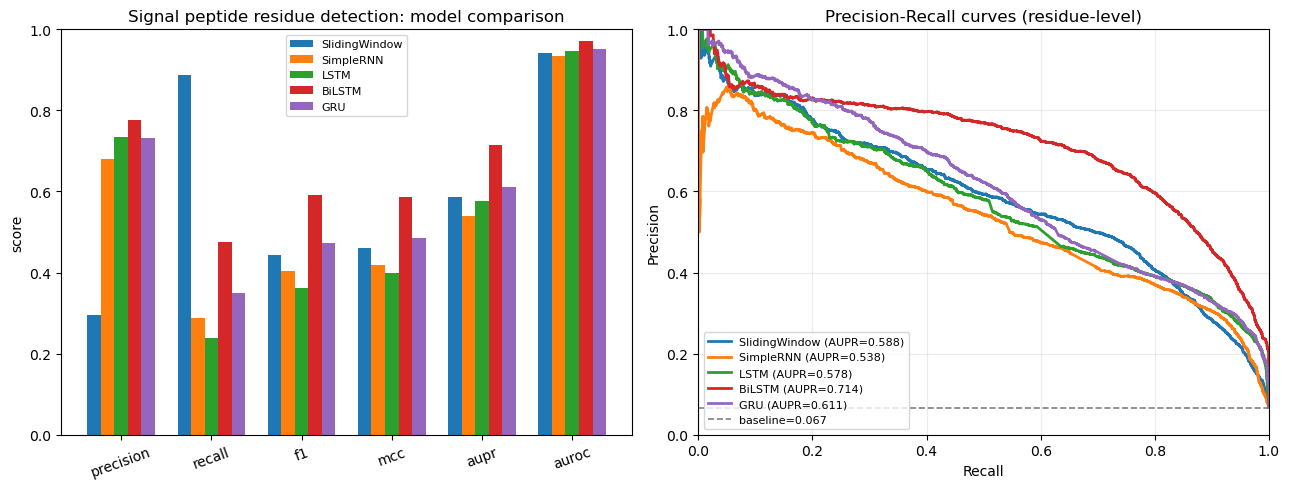

In [8]:
metric_names = ["precision", "recall", "f1", "mcc", "aupr", "auroc"]
model_names = list(results.keys())

print("Final test metrics")
for name in model_names:
    print(f"\n[{name}]" + (f"  ({param_counts[name]:,} params)" if name in param_counts else ""))
    for m in metric_names:
        print(f"  {m:>9s}: {results[name][m]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(metric_names))
w = 0.15
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metric_names]
    axes[0].bar(x + (i - 2) * w, vals, width=w, label=name)
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names, rotation=20)
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel("score")
axes[0].set_title("Signal peptide residue detection: model comparison")
axes[0].legend(fontsize=8)

for name in model_names:
    y_true, p = results[name]["y"], results[name]["proba"]
    pr, rc, _ = precision_recall_curve(y_true, p)
    ap = average_precision_score(y_true, p)
    axes[1].plot(rc, pr, linewidth=2, label=f"{name} (AUPR={ap:.3f})")
baseline = np.mean(results["SlidingWindow"]["y"])
axes[1].axhline(baseline, linestyle="--", color="gray", linewidth=1.2, label=f"baseline={baseline:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (residue-level)")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].legend(loc="lower left", fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../figs/day11-model-comparison.png", dpi=130)
plt.show()

## 5) Protein language models: the same recurrent building blocks, pretrained at scale

**UniRep** (Alley, Khimulya, Biswas, AlQuraishi & Church, *Nature Methods* 2019) is a real protein language model built on exactly the recurrent machinery above — a **multiplicative LSTM (mLSTM)**, trained by next-amino-acid prediction on ~24 million UniRef50 sequences. No labels, no annotation: the model just learns to predict the next residue given the ones before it, the same self-supervised idea as GPT-style language models, but for protein sequences and built on an LSTM rather than a Transformer. The resulting fixed-length representations turned out to be useful for predicting secondary structure, stability, and function — this is what "protein language model" means at the representation-learning level, using only the RNN/LSTM machinery this day already covers.

SignalP's own history (mined above) makes the next step concrete: SignalP 5.0 (2019) used exactly this day's toolkit — CNN + LSTM + a CRF layer. SignalP 6.0 (2022) replaced the LSTM component with **ProtBERT**, a Transformer-based protein language model, fine-tuned for signal-peptide prediction. The same case study this notebook just built a small version of, upgraded from this day's architecture family to next week's.

A second, more recent example: **ProstT5** ([Heinzinger et al., 2023/2024](https://github.com/mheinzinger/ProstT5), TU Munich/Rost lab) is a T5-based (Transformer) protein language model that translates between amino-acid sequence and 3Di structure tokens (Foldseek's structural alphabet) — a real, current example of what a protein language model can do, described here purely at the level of *what it does*. **How Transformer-based models like ProtBERT and ProstT5 actually work internally — self-attention — is Day 12's job, not this one.**

## Try it yourself

Change `MAX_RECORDS`, `NTERM_LEN`, or the recurrent hidden size, and re-run — in particular, try `hid_dim=16` (a much smaller model) and see how much of BiLSTM/GRU's advantage over SimpleRNN survives.